In [1]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
import tensorflow as tf
from tensorflow.keras import layers, models

# Configuration
IMG_SIZE = (224, 224) # Standard size for CNN input
DATA_PATH = 'D:\\VIT\\Dataset\\number_plate_detection'

In [2]:
def load_data_augmented(base_path):
    images = []
    labels = []

    for root, dirs, files in os.walk(base_path):
        for file in files:
            if file.endswith(".jpg"):
                img_path = os.path.join(root, file)
                txt_path = img_path.replace(".jpg", ".txt")

                if os.path.exists(txt_path):
                    img = cv2.imread(img_path)
                    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
                    h, w, _ = img.shape
                    
                    with open(txt_path, 'r') as f:
                        line = f.readline().strip().split()
                        if not line: continue 
                        _, x_c, y_c, w_n, h_n = map(float, line)
                        
                        # Convert to xmin, ymin, xmax, ymax
                        xmin, ymin = x_c - (w_n/2), y_c - (h_n/2)
                        xmax, ymax = x_c + (w_n/2), y_c + (h_n/2)

                    # --- ADDING A DATA AUGMENTATION STEP HERE ---
                    # To fix the 'line' issue, we sometimes crop closer to the plate
                    if np.random.rand() > 0.5:
                        # Create a random crop that still contains the plate
                        c_xmin = max(0, xmin - np.random.uniform(0.1, 0.3))
                        c_ymin = max(0, ymin - np.random.uniform(0.1, 0.3))
                        c_xmax = min(1, xmax + np.random.uniform(0.1, 0.3))
                        c_ymax = min(1, ymax + np.random.uniform(0.1, 0.3))
                        
                        # Crop the actual image pixels
                        img = img[int(c_ymin*h):int(c_ymax*h), int(c_xmin*w):int(c_xmax*w)]
                        
                        # Recalculate label relative to the new crop
                        crop_w, crop_h = (c_xmax - c_xmin), (c_ymax - c_ymin)
                        xmin = (xmin - c_xmin) / crop_w
                        ymin = (ymin - c_ymin) / crop_h
                        xmax = (xmax - c_xmin) / crop_w
                        ymax = (ymax - c_ymin) / crop_h
                    
                    img_resized = cv2.resize(img, (224, 224))
                    images.append(img_resized / 255.0)
                    labels.append([xmin, ymin, xmax, ymax])

    return np.array(images), np.array(labels)

X, y = load_data_augmented(DATA_PATH)
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

In [3]:
def build_robust_model():
    model = models.Sequential([
        # Block 1
        layers.Conv2D(32, (3, 3), padding='same', input_shape=(224, 224, 3)),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 2
        layers.Conv2D(64, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Block 3
        layers.Conv2D(128, (3, 3), padding='same'),
        layers.BatchNormalization(),
        layers.Activation('relu'),
        layers.MaxPooling2D((2, 2)),
        
        # Head
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.BatchNormalization(),
        layers.Dropout(0.3),
        layers.Dense(4, activation='sigmoid') # Sigmoid is perfect for 0-1 normalized coordinates
    ])
    
    # We use a slightly lower learning rate for stability
    optimizer = tf.keras.optimizers.Adam(learning_rate=0.0005)
    model.compile(optimizer=optimizer, loss='mse', metrics=['mae'])
    return model

model = build_robust_model()
model.summary()

C:\Users\Parth\anaconda3\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 224, 224, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization                  │ (None, 224, 224, 32)        │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation (Activation)              │ (None, 224, 224, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 112, 112, 32)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 112, 112, 64)        │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_1                │ (None, 112, 112, 64)        │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_1 (Activation)            │ (None, 112, 112, 64)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 56, 56, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 56, 56, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_2                │ (None, 56, 56, 128)         │             512 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ activation_2 (Activation)            │ (None, 56, 56, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 28, 28, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 100352)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 256)                 │      25,690,368 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_3                │ (None, 256)                 │           1,024 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 256)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 4)                   │           1,028 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 25,786,564 (98.37 MB)

 Trainable params: 25,785,604 (98.36 MB)

 Non-trainable params: 960 (3.75 KB)

In [ ]:
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping

# Callbacks for better convergence
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)
early_stop = EarlyStopping(monitor='val_loss', patience=10, restore_best_weights=True)

history = model.fit(
    X_train, y_train,
    validation_data=(X_val, y_val),
    epochs=50, # Increased epochs since we have a scheduler now
    batch_size=16,
    callbacks=[lr_reducer, early_stop]
)

Epoch 1/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 14s 937ms/step - loss: 0.1237 - mae: 0.2907 - val_loss: 0.0605 - val_mae: 0.2026 - learning_rate: 5.0000e-04
Epoch 2/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 851ms/step - loss: 0.0729 - mae: 0.2174 - val_loss: 0.0457 - val_mae: 0.1738 - learning_rate: 5.0000e-04
Epoch 3/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 836ms/step - loss: 0.0626 - mae: 0.1967 - val_loss: 0.0447 - val_mae: 0.1736 - learning_rate: 5.0000e-04
Epoch 4/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 836ms/step - loss: 0.0442 - mae: 0.1671 - val_loss: 0.0459 - val_mae: 0.1760 - learning_rate: 5.0000e-04
Epoch 5/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 847ms/step - loss: 0.0422 - mae: 0.1618 - val_loss: 0.0456 - val_mae: 0.1750 - learning_rate: 5.0000e-04
Epoch 6/50
8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 778ms/step - loss: 0.0380 - mae: 0.1483
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0002500000118743628.
8/8 ━━━━━━━━━━━━━━━━━━━━ 7s 826ms/step - loss: 0.0349 - mae: 0.1418 - val_loss: 0.0456 - val_mae: 0.1741 - learning_rate: 5.

In [5]:
def calculate_iou(boxA, boxB):
    # box format: [xmin, ymin, xmax, ymax]
    xA = max(boxA[0], boxB[0])
    yA = max(boxA[1], boxB[1])
    xB = min(boxA[2], boxB[2])
    yB = min(boxA[3], boxB[3])

    interWidth = max(0, xB - xA)
    interHeight = max(0, yB - yA)
    interArea = interWidth * interHeight

    boxAArea = (boxA[2] - boxA[0]) * (boxA[3] - boxA[1])
    boxBArea = (boxB[2] - boxB[0]) * (boxB[3] - boxB[1])

    iou = interArea / float(boxAArea + boxBArea - interArea + 1e-6)
    return iou

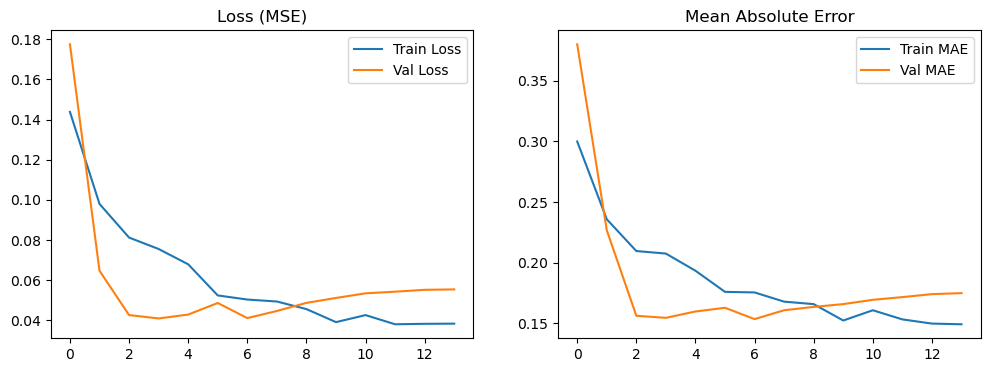

In [6]:
plt.figure(figsize=(12, 4))

# Plot Loss (MSE)
plt.subplot(1, 2, 1)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.title('Loss (MSE)')
plt.legend()

# Plot MAE (Mean Absolute Error)
plt.subplot(1, 2, 2)
plt.plot(history.history['mae'], label='Train MAE')
plt.plot(history.history['val_mae'], label='Val MAE')
plt.title('Mean Absolute Error')
plt.legend()

plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 137ms/step


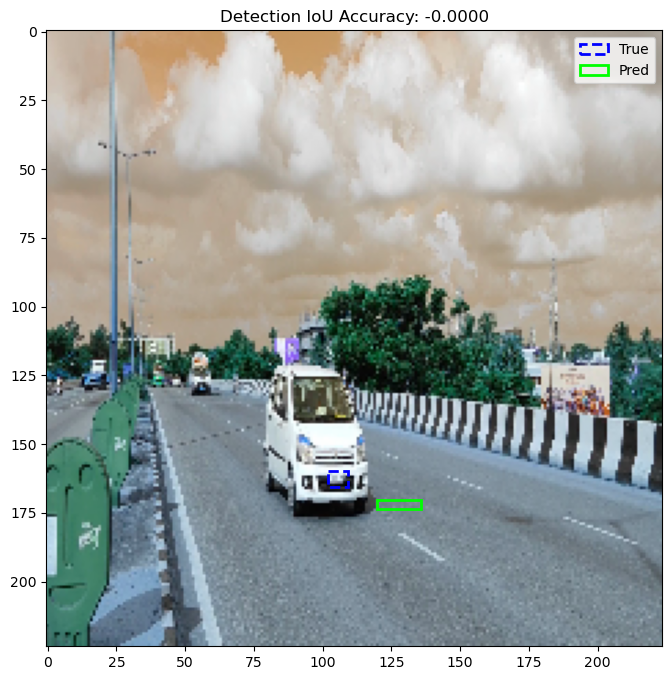

In [9]:
def predict_and_compare(img_idx):
    img = X_val[img_idx]
    true_box = y_val[img_idx]
    
    # Predict
    pred = model.predict(np.expand_dims(img, axis=0))[0]
    
    # Calculate Accuracy
    iou_score = calculate_iou(true_box, pred)
    
    # Display
    plt.figure(figsize=(8, 8))
    plt.imshow(img)
    ax = plt.gca()
    
    # Scale coordinates to the 224x224 display size
    # True Box (Blue dashed)
    rect_t = plt.Rectangle((true_box[0]*224, true_box[1]*224), 
                            (true_box[2]-true_box[0])*224, 
                            (true_box[3]-true_box[1])*224, 
                            fill=False, color='blue', linestyle='--', linewidth=2, label='True')
    
    # Predicted Box (Green solid)
    rect_p = plt.Rectangle((pred[0]*224, pred[1]*224), 
                            (pred[2]-pred[0])*224, 
                            (pred[3]-pred[1])*224, 
                            fill=False, color='lime', linewidth=2, label='Pred')
    
    ax.add_patch(rect_t)
    ax.add_patch(rect_p)
    plt.title(f"Detection IoU Accuracy: {iou_score:.4f}")
    plt.legend()
    plt.show()

# Run the test
predict_and_compare(10)